In [2]:
import torch

if torch.cuda.is_available():
    print("GPU disponibile!")
    print("Nome GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU NON disponibile.")

GPU disponibile!
Nome GPU: Tesla T4


# Import and Seed

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Bidirectional, Dropout, LeakyReLU
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    BackupAndRestore,
    CSVLogger
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt


import os
import json
import itertools
import shutil
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Bidirectional, Dropout, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, CSVLogger

SEED = 100
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

SEED = 100

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Seed impostato a:", SEED)

TensorFlow version: 2.19.0
Seed impostato a: 100


# Dataset Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Ds/financial_news_base.jsonl"
#file_path = "/content/drive/MyDrive/financial_news_base.jsonl"

df = pd.read_json(file_path, lines=True)

df.head()

Mounted at /content/drive


,date_publish,description,maintext,title,mentioned_companies,related_companies,industries,sentiment,emotion,sentiment_label
0,2018-06-22 18:39:00,Morgan Stanley is telling its clients to pay a...,Morgan Stanley is telling its clients to pay a...,Morgan Stanley sees 'a pattern forming' of the...,[GOOGL],"[IGLD, RAMP, NSR, TWTR, ACXM, COR, PINS, META,...",[7375],"{'negative': 0.0005622319, 'neutral': 0.006970...","{'neutral': 0.9212942719, 'surprise': 0.039100...",positive
1,2018-11-15 00:00:00,"The FCC voted to grant ""market access"" request...",By David Shepardson\nWASHINGTON (Reuters - The...,"SpaceX, TeleSat Canada bids get U.S. nod to ex...","[TSLA, MU]","[IKGH, CLLS, EBIO, GMAB, GBS, WIMI, WALD, FGEN...","[3674, 9999]","{'negative': 0.0002858295, 'neutral': 0.001688...","{'neutral': 0.8668617606000001, 'joy': 0.05769...",positive
2,2018-12-29 19:57:55,(Bloomberg) -- A lawsuit filed against Google ...,(Bloomberg) -- A lawsuit filed against Google ...,Google Wins Dismissal of Suit Over Facial Reco...,[GOOGL],"[IGLD, RAMP, NSR, TWTR, ACXM, COR, PINS, META,...",[7375],"{'negative': 0.2307210714, 'neutral': 0.361657...","{'anger': 0.7141016126, 'neutral': 0.202039063...",positive
3,2018-09-12 18:42:40,"With camera upgrades, better screens and more",Apple on Wednesday unveiled a trio of new iPho...,"Apple Unveils iPhone XS, iPhone XS Max and Che...",[AAPL],"[None, TDC, HPQ, SCKT, OMCL, CRAY, ZEPP, IBM, ...",[3571],"{'negative': 0.0053426563, 'neutral': 0.164953...","{'neutral': 0.9592552185000001, 'surprise': 0....",positive
4,2018-04-23 20:03:16,Google is reporting on Monday.,"Google’s (GOOG, GOOGL) parent company Alphabet...",Alphabet Q1 2018 earnings,"[GOOGL, INTC, META, AAPL]","[IGLD, TDC, NSAT, CRAY, TCX, FLEX, SMCI, WBMD,...","[3571, 3679, 7375]","{'negative': 0.0003154654, 'neutral': 5.86179e...","{'neutral': 0.6759750247, 'surprise': 0.166648...",positive


# Class Balancing

In [3]:
from transformers import DistilBertTokenizer as _TempTokenizer

MAX_LEN = 256

# Step 1: Filter rows with more than 256 tokens on the ORIGINAL dataset (before balancing)
_tokenizer_temp = _TempTokenizer.from_pretrained("distilbert-base-uncased")
mask_256 = df["description"].apply(
    lambda t: len(_tokenizer_temp.encode(str(t), add_special_tokens=True)) <= MAX_LEN
)
df_filtered = df[mask_256].reset_index(drop=True)
print(f"Original rows: {len(df)} — After {MAX_LEN} token filter: {len(df_filtered)}")
print("\nClass distribution after filtering:")
print(df_filtered["sentiment_label"].value_counts())

# Step 2: Balance classes AFTER filtering
target_per_class = 25000 // 3

dfs = []
for label in df_filtered["sentiment_label"].unique():
    subset = df_filtered[df_filtered["sentiment_label"] == label]
    dfs.append(subset.sample(n=target_per_class, random_state=100))

df_balanced = pd.concat(dfs).sample(frac=1, random_state=100).reset_index(drop=True)
print(f"\nBalanced dataset size: {len(df_balanced)}")
print(df_balanced["sentiment_label"].value_counts())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1534 > 512). Running this sequence through the model will result in indexing errors


Original rows: 70547 — After 256 token filter: 67111

Class distribution after filtering:
sentiment_label
positive    36819
neutral     18666
negative    11626
Name: count, dtype: int64

Balanced dataset size: 24999
sentiment_label
negative    8333
positive    8333
neutral     8333
Name: count, dtype: int64


# Preparing Features (X) and Labels (y)

In [5]:
X_texts = df_balanced["description"].fillna("").astype(str).values

label_map = {
     "positive": 0,
     "negative": 1,
     "neutral": 2
}

y = (
    df_balanced["sentiment_label"]
    .astype(str)
    .str.lower()
    .map(label_map)
    .values
)

mask = ~pd.isna(y)
X_texts = X_texts[mask]
y = y[mask].astype("int32")

print(len(X_texts))
print("Class counts:", np.bincount(y))

24999
Class counts: [8333 8333 8333]


# Train / Validation / Test Split

In [6]:
X_train_texts, X_temp_texts, y_train, y_temp = train_test_split(
    X_texts,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val_texts, X_test_texts, y_val, y_test = train_test_split(
    X_temp_texts,
    y_temp,
    test_size=0.50,
    random_state=SEED,

    stratify=y_temp
)

print("Train size:", len(X_train_texts), " - class balance:", np.bincount(y_train))
print("Val size:  ", len(X_val_texts),   " - class balance:", np.bincount(y_val))
print("Test size: ", len(X_test_texts),  " - class balance:", np.bincount(y_test))

Train size: 17499  - class balance: [5833 5833 5833]
Val size:   3750  - class balance: [1250 1250 1250]
Test size:  3750  - class balance: [1250 1250 1250]


# Tokenization and Sequence Padding

In [7]:
VOCAB_SIZE = 50000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_texts)

train_seq = tokenizer.texts_to_sequences(X_train_texts)
val_seq   = tokenizer.texts_to_sequences(X_val_texts)
test_seq  = tokenizer.texts_to_sequences(X_test_texts)

lengths = np.array([len(s) for s in train_seq])

print("Percentili lunghezze sequenze:", np.percentile(lengths, [50, 75, 90, 95, 99, 100]).astype(int))

MAX_SEQUENCE_LEN = int(np.percentile(lengths, 95))
MAX_SEQUENCE_LEN = min(MAX_SEQUENCE_LEN, 256)
MAX_SEQUENCE_LEN = max(MAX_SEQUENCE_LEN, 50)

print("MAX_SEQUENCE_LEN:", MAX_SEQUENCE_LEN)

X_train = pad_sequences(
    train_seq,
    maxlen=MAX_SEQUENCE_LEN,
    padding="post",
    truncating="post"
).astype("int32")

X_val = pad_sequences(
    val_seq,
    maxlen=MAX_SEQUENCE_LEN,
    padding="post",
    truncating="post"
).astype("int32")

X_test = pad_sequences(
    test_seq,
    maxlen=MAX_SEQUENCE_LEN,
    padding="post",
    truncating="post"
).astype("int32")

y_train = y_train.astype("int32")
y_val   = y_val.astype("int32")
y_test  = y_test.astype("int32")

print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("y_train shape:", y_train.shape, "dtype:", y_train.dtype)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

assert int(X_train.max()) < VOCAB_SIZE, f"Indice fuori range: {X_train.max()} >= {VOCAB_SIZE}"

Percentili lunghezze sequenze: [ 51  77  86  98 125 219]
MAX_SEQUENCE_LEN: 98
X_train shape: (17499, 98) dtype: int32
y_train shape: (17499,) dtype: int32
Val shape: (3750, 98)
Test shape: (3750, 98)


# Saving Tokenizer and Configuration

In [8]:
SAVE_DIR = "/content/drive/MyDrive/Ds/bilstm_glove_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

tokenizer_json = tokenizer.to_json()
with open(os.path.join(SAVE_DIR, "tokenizer.json"), "w", encoding="utf-8") as f:
    f.write(tokenizer_json)

config = {
    "SEED": SEED,
    "VOCAB_SIZE": VOCAB_SIZE,
    "MAX_SEQUENCE_LEN": int(MAX_SEQUENCE_LEN),
    "OOV_TOKEN": OOV_TOKEN,
    "label_map": label_map
}

with open(os.path.join(SAVE_DIR, "config.json"), "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Tokenizer e config salvati in:", SAVE_DIR)

Tokenizer e config salvati in: /content/drive/MyDrive/Ds/bilstm_glove_checkpoints


# Loading GloVe Embeddings

In [11]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2026-03-10 17:37:00--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-10 17:37:00--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-10 17:37:00--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [12]:
EMBED_DIM = 100
glove_path = "/content/glove.6B.100d.txt"

print("GloVe exists?", os.path.exists(glove_path))

embeddings_index = {}
with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.rstrip().split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print("Loaded GloVe vectors:", len(embeddings_index))

GloVe exists? True
Loaded GloVe vectors: 400000


# Building the Embedding Matrix

In [13]:
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype="float32")

for word, i in tokenizer.word_index.items():
    if i >= VOCAB_SIZE:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec

print("embedding_matrix shape:", embedding_matrix.shape)
print("embedding_matrix dtype:", embedding_matrix.dtype)

embedding_matrix shape: (50000, 100)
embedding_matrix dtype: float32


# Tuning configuration

In [14]:
# Tuning parametri
TUNING_DIR = "/content/drive/MyDrive/Ds/bilstm_glove_gridsearch"
os.makedirs(TUNING_DIR, exist_ok=True)

SEARCH_EPOCHS = 7
FINAL_EPOCHS = 20
BATCH_SIZE = 32

LSTM_UNITS_LIST = [32, 64, 96]
DENSE_UNITS_LIST = [32, 64, 128]
DROPOUT_LIST = [0.2, 0.3, 0.4]
LEARNING_RATE_LIST = [1e-3, 5e-4, 2e-4]

RESULTS_CSV = os.path.join(TUNING_DIR, "grid_search_results.csv")
BEST_CONFIG_JSON = os.path.join(TUNING_DIR, "best_config.json")

print("Tuning directory:", TUNING_DIR)
print("Total combinations:", len(LSTM_UNITS_LIST) * len(DENSE_UNITS_LIST) * len(DROPOUT_LIST) * len(LEARNING_RATE_LIST))

Tuning directory: /content/drive/MyDrive/Ds/bilstm_glove_gridsearch
Total combinations: 81


# Model builder

In [15]:
def build_bilstm_model(vocab_size, embed_dim, embedding_matrix,
                       max_sequence_len,
                       lstm_units, dense_units, dropout_rate, learning_rate):

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embedding_matrix],
            trainable=False,
            mask_zero=True
        ),
        SpatialDropout1D(dropout_rate),
        Bidirectional(LSTM(lstm_units, dropout=dropout_rate)),
        Dense(dense_units),
        LeakyReLU(negative_slope=0.1),
        Dropout(dropout_rate),
        Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.build(input_shape=(None, max_sequence_len))
    return model

# Model architecture over

In [ ]:
# evidenziare layer del modello
reference_model = build_bilstm_model(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    embedding_matrix=embedding_matrix,
    max_sequence_len=MAX_SEQUENCE_LEN,
    lstm_units=64,
    dense_units=64,
    dropout_rate=0.3,
    learning_rate=1e-3
)

reference_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 143, 100)       │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 143, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,092,931 (19.43 MB)

 Trainable params: 92,931 (363.01 KB)

 Non-trainable params: 5,000,000 (19.07 MB)

# Parameter grid

In [16]:
# griglia dei valori
param_grid = list(itertools.product(
    LSTM_UNITS_LIST,
    DENSE_UNITS_LIST,
    DROPOUT_LIST,
    LEARNING_RATE_LIST
))

grid_df = pd.DataFrame(param_grid, columns=[
    "lstm_units",
    "dense_units",
    "dropout_rate",
    "learning_rate"
])

grid_df["trial_id"] = [f"trial_{i:03d}" for i in range(len(grid_df))]
grid_df = grid_df[["trial_id", "lstm_units", "dense_units", "dropout_rate", "learning_rate"]]

print(grid_df.head())
print("Number of trials:", len(grid_df))

    trial_id  lstm_units  dense_units  dropout_rate  learning_rate
0  trial_000          32           32           0.2         0.0010
1  trial_001          32           32           0.2         0.0005
2  trial_002          32           32           0.2         0.0002
3  trial_003          32           32           0.3         0.0010
4  trial_004          32           32           0.3         0.0005
Number of trials: 81


# Resume logic

In [ ]:
# ricaricare vecchio modello se stato interrotto
if os.path.exists(RESULTS_CSV):
    results_df = pd.read_csv(RESULTS_CSV)
    completed_trials = set(results_df["trial_id"].astype(str).tolist())
    print(f"Found existing results file with {len(completed_trials)} completed trials.")
else:
    results_df = pd.DataFrame()
    completed_trials = set()
    print("No previous results found. Starting from scratch.")

Found existing results file with 79 completed trials.


# Exhaustive grid search

In [ ]:
all_results = []

if os.path.exists(RESULTS_CSV):
    all_results = pd.read_csv(RESULTS_CSV).to_dict("records")

for _, row in grid_df.iterrows():
    trial_id = row["trial_id"]

    if trial_id in completed_trials:
        print(f"Skipping {trial_id} (already completed).")
        continue

    lstm_units = int(row["lstm_units"])
    dense_units = int(row["dense_units"])
    dropout_rate = float(row["dropout_rate"])
    learning_rate = float(row["learning_rate"])

    print("\n" + "=" * 100)
    print(f"Starting {trial_id}")
    print(f"lstm_units={lstm_units}, dense_units={dense_units}, dropout_rate={dropout_rate}, learning_rate={learning_rate}")
    print("=" * 100)

    trial_dir = os.path.join(TUNING_DIR, trial_id)
    os.makedirs(trial_dir, exist_ok=True)

    trial_log_path = os.path.join(trial_dir, "training_log.csv")
    trial_model_path = os.path.join(trial_dir, "best_model.keras")
    trial_result_path = os.path.join(trial_dir, "result.json")

    model = build_bilstm_model(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        embedding_matrix=embedding_matrix,
        max_sequence_len=MAX_SEQUENCE_LEN,
        lstm_units=lstm_units,
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate
    )

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=trial_model_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=0
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=1
        ),
        CSVLogger(trial_log_path, append=False)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=SEARCH_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    best_epoch_idx = int(np.argmin(history.history["val_loss"]))
    best_val_loss = float(history.history["val_loss"][best_epoch_idx])
    best_val_acc = float(history.history["val_accuracy"][best_epoch_idx])
    best_train_loss = float(history.history["loss"][best_epoch_idx])
    best_train_acc = float(history.history["accuracy"][best_epoch_idx])
    epochs_ran = len(history.history["loss"])

    result = {
        "trial_id": trial_id,
        "lstm_units": lstm_units,
        "dense_units": dense_units,
        "dropout_rate": dropout_rate,
        "learning_rate": learning_rate,
        "best_epoch": best_epoch_idx + 1,
        "epochs_ran": epochs_ran,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_acc,
        "best_train_loss": best_train_loss,
        "best_train_accuracy": best_train_acc,
        "model_path": trial_model_path
    }

    with open(trial_result_path, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    all_results.append(result)
    pd.DataFrame(all_results).to_csv(RESULTS_CSV, index=False)

    print(f"Completed {trial_id}")
    print(f"Best epoch: {result['best_epoch']}")
    print(f"Best val_loss: {best_val_loss:.4f}")
    print(f"Best val_accuracy: {best_val_acc:.4f}")

Skipping trial_000 (already completed).
Skipping trial_001 (already completed).
Skipping trial_002 (already completed).
Skipping trial_003 (already completed).
Skipping trial_004 (already completed).
Skipping trial_005 (already completed).
Skipping trial_006 (already completed).
Skipping trial_007 (already completed).
Skipping trial_008 (already completed).
Skipping trial_009 (already completed).
Skipping trial_010 (already completed).
Skipping trial_011 (already completed).
Skipping trial_012 (already completed).
Skipping trial_013 (already completed).
Skipping trial_014 (already completed).
Skipping trial_015 (already completed).
Skipping trial_016 (already completed).
Skipping trial_017 (already completed).
Skipping trial_018 (already completed).
Skipping trial_019 (already completed).
Skipping trial_020 (already completed).
Skipping trial_021 (already completed).
Skipping trial_022 (already completed).
Skipping trial_023 (already completed).
Skipping trial_024 (already completed).


# Rank configurations
check non ancora runnato

In [ ]:
results_df = pd.read_csv(RESULTS_CSV)

ranked_df = results_df.sort_values(
    by=["best_val_loss", "best_val_accuracy"],
    ascending=[True, False]
).reset_index(drop=True)

ranked_df["rank"] = np.arange(1, len(ranked_df) + 1)

display(ranked_df.head(10))

,trial_id,lstm_units,dense_units,dropout_rate,learning_rate,best_epoch,epochs_ran,best_val_loss,best_val_accuracy,best_train_loss,best_train_accuracy,model_path,rank
0,trial_063,96,64,0.2,0.0010,7,7,0.870568,0.593600,0.822310,0.624779,/content/drive/MyDrive/Ds/bilstm_glove_gridsea...,1
1,trial_054,96,32,0.2,0.0010,7,7,0.872466,0.601067,0.828424,0.618892,/content/drive/MyDrive/Ds/bilstm_glove_gridsea...,2
2,trial_057,96,32,0.3,0.0010,7,7,0.873686,0.596800,0.884944,0.589577,/content/drive/MyDrive/Ds/bilstm_glove_gridsea...,3
3,trial_066,96,64,0.3,0.0010,7,7,0.874705,0.590133,0.878740,0.587634,/content/drive/MyDrive/Ds/bilstm_glove_gridsea...,4
4,trial_000,32,32,0.2,0.0010,7,7,0.874720,0.598400,0.867817,0.598320,/content/drive/MyDrive/Ds/bilstm_glove_gridsea...,5
5,trial_027,64,32,0.2,0.0010,7,7,0.875361,0.596800,0.844175,0.614664,/content/drive/MyDrive/Ds/bilstm_glove_gridsea...,6
6,trial_018,32,128,0.2,0.0010,7,7,0.876380,0.592267,0.857795,0.603063,/content/drive/MyDrive/Ds/bilstm_glove_gridsea...,7
7,trial_045,64,128,0.2,0.0010,7,7,0.876390,0.598933,0.834379,0.621293,/content/drive/MyDrive/Ds/bilstm_glove_gridsea...,8
8,trial_055,96,32,0.2,0.0005,7,7,0.877448,0.591733,0.869693,0.594891,/content/drive/MyDrive/Ds/bilstm_glove_gridsea...,9
9,trial_009,32,64,0.2,0.0010,7,7,0.877608,0.593067,0.862897,0.606720,/content/drive/MyDrive/Ds/bilstm_glove_gridsea...,10


# Save best configuration

In [ ]:
best_row = ranked_df.iloc[0].to_dict()

with open(BEST_CONFIG_JSON, "w", encoding="utf-8") as f:
    json.dump(best_row, f, indent=2)

print("Best configuration selected automatically:")
print(json.dumps(best_row, indent=2))

Best configuration selected automatically:
{
  "trial_id": "trial_063",
  "lstm_units": 96,
  "dense_units": 64,
  "dropout_rate": 0.2,
  "learning_rate": 0.001,
  "best_epoch": 7,
  "epochs_ran": 7,
  "best_val_loss": 0.8705682158470154,
  "best_val_accuracy": 0.5935999751091003,
  "best_train_loss": 0.8223101496696472,
  "best_train_accuracy": 0.6247785687446594,
  "model_path": "/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_063/best_model.keras",
  "rank": 1
}


# Rebuild and train the best model

In [23]:
with open(BEST_CONFIG_JSON, "r", encoding="utf-8") as f:
    best_config = json.load(f)

best_lstm_units = int(best_config["lstm_units"])
best_dense_units = int(best_config["dense_units"])
best_dropout_rate = float(best_config["dropout_rate"])
best_learning_rate = float(best_config["learning_rate"])

print("Best hyperparameters:")
print(best_config)

final_model = build_bilstm_model(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    embedding_matrix=embedding_matrix,
    max_sequence_len=MAX_SEQUENCE_LEN,
    lstm_units=best_lstm_units,
    dense_units=best_dense_units,
    dropout_rate=best_dropout_rate,
    learning_rate=best_learning_rate
)

FINAL_MODEL_DIR = os.path.join(TUNING_DIR, "final_best_model")
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

final_model_path = os.path.join(FINAL_MODEL_DIR, "best_final_model.keras")
final_log_path = os.path.join(FINAL_MODEL_DIR, "final_training_log.csv")

final_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=final_model_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    ),
    CSVLogger(final_log_path, append=False)
]

final_history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=FINAL_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=final_callbacks,
    verbose=1
)

Best hyperparameters:
{'trial_id': 'trial_063', 'lstm_units': 96, 'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'best_epoch': 7, 'epochs_ran': 7, 'best_val_loss': 0.8705682158470154, 'best_val_accuracy': 0.5935999751091003, 'best_train_loss': 0.8223101496696472, 'best_train_accuracy': 0.6247785687446594, 'model_path': '/content/drive/MyDrive/Ds/bilstm_glove_gridsearch/trial_063/best_model.keras', 'rank': 1}
Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4565 - loss: 1.0356
Epoch 1: val_loss improved from inf to 0.94054, saving model to /content/drive/MyDrive/Ds/bilstm_glove_gridsearch/final_best_model/best_final_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.4566 - loss: 1.0355 - val_accuracy: 0.5469 - val_loss: 0.9405 - learning_rate: 0.0010
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5410 - loss: 0.9444
Epoch 2: val_loss improved from 0.94054 to 0.90969, saving model to /content/drive/MyDrive/Ds/bilstm

Columns in log file: Index(['epoch', 'accuracy', 'learning_rate', 'loss', 'val_accuracy',
       'val_loss'],
      dtype='object')


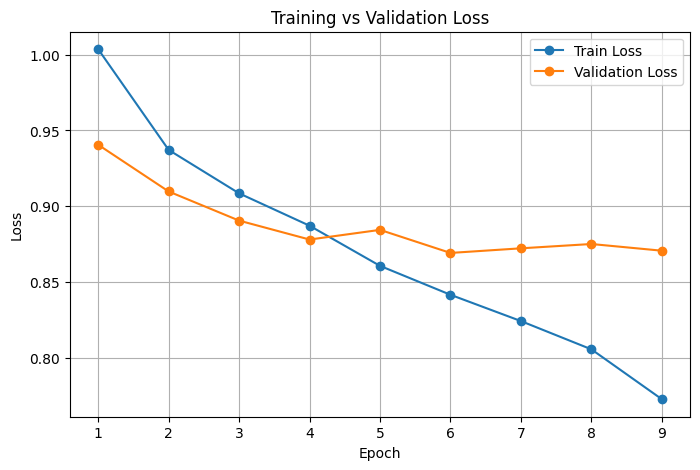

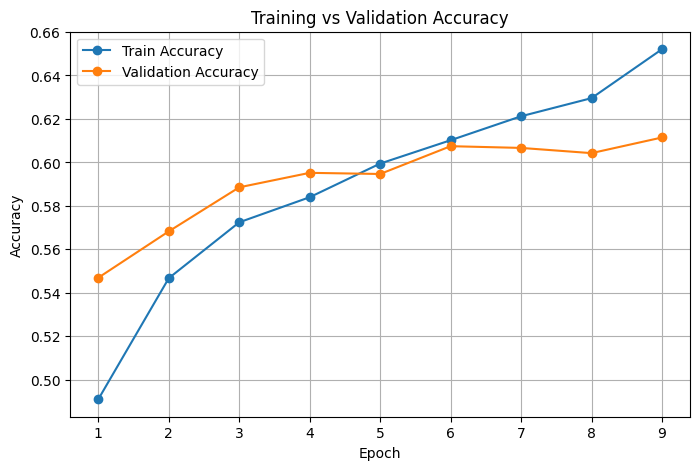

In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt

if not os.path.exists(final_log_path):
    raise FileNotFoundError(f"Training log not found: {final_log_path}")

log_df = pd.read_csv(final_log_path)

print("Columns in log file:", log_df.columns)

epochs = log_df["epoch"] + 1

train_loss = log_df["loss"]
val_loss = log_df["val_loss"]

train_acc = log_df["accuracy"]
val_acc = log_df["val_accuracy"]

# Loss
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, marker="o", label="Train Loss")
plt.plot(epochs, val_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, marker="o", label="Train Accuracy")
plt.plot(epochs, val_acc, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Model Evaluation on the Test Set

In [25]:
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6230 - loss: 0.8531
Test Loss: 0.8516
Test Accuracy: 0.6173


In [26]:
y_test_pred_probs = final_model.predict(X_test)

y_test_pred = np.argmax(y_test_pred_probs, axis=1)

print("Predictions shape:", y_test_pred.shape)

118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step
Predictions shape: (3750,)


In [27]:
class_names = ["negative", "neutral", "positive"]

report = classification_report(
    y_test,
    y_test_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

    negative       0.57      0.60      0.58      1250
     neutral       0.67      0.59      0.63      1250
    positive       0.61      0.66      0.64      1250

    accuracy                           0.62      3750
   macro avg       0.62      0.62      0.62      3750
weighted avg       0.62      0.62      0.62      3750



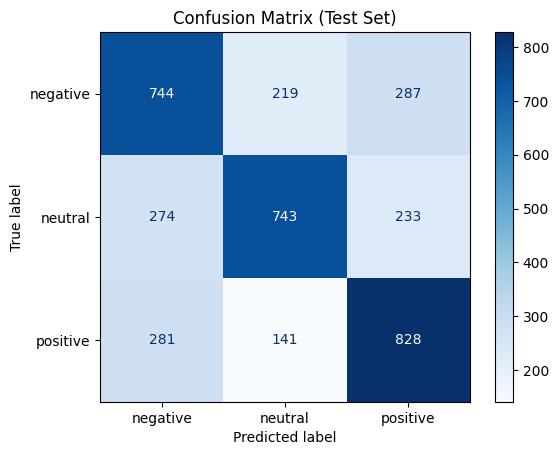

In [28]:
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.show()

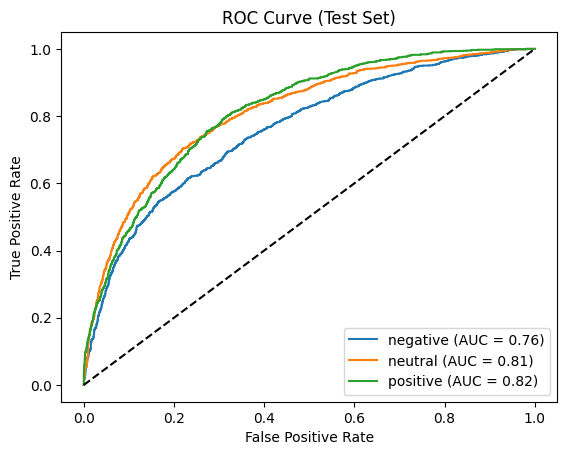

In [29]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

n_classes = 3

plt.figure()

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_test_pred_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()

In [ ]:
for i in range(5):

    print("Text:")
    print(X_val_texts[i])
    print()

    print("True label:", class_names[y_val[i]])
    print("Predicted:", class_names[y_val_pred[i]])

    print("-"*80)

Text:
(Bloomberg) -- New lawsuits filed by the US Securities and Exchange Commission against Coinbase Global Inc. and Binance Holdings Ltd. have raised serious questions about the future of crypto.Most Read from BloombergThe Wagner Mutiny Foreshadows a Russian DefeatWagner Chief Directly Challenges Putin as Russia Crisis SpiralsGoldman Sachs Is Cutting About 125 Managing Directors GloballyPrigozhin Accused of Uprising in Challenge to Kremlin GripRussia Latest: Prigozhin’s Wagner Forces Seen Headed to

True label: negative
Predicted: negative
--------------------------------------------------------------------------------
Text:
A week after launching a new universal search and discovery tool, Plex is inconveniencing podcast listeners by removing support for podcasts and web shows this Friday, April 15. You can continue to access these features within Plex until Friday, April 15th, 2022, at which point they will no longer be available. Podcasts within Plex were first added in 2018 as wer

# Loading the Best Saved Model

In [17]:
final_model = tf.keras.models.load_model(
    os.path.join(TUNING_DIR, "final_best_model", "best_final_model.keras")
)

print("Best final model loaded successfully.")

Best final model loaded successfully.


# Vecchi codici

In [ ]:
# Create a clean summary table
class_distribution = (
    df['sentiment_label']
    .value_counts()
    .rename_axis('Sentiment')
    .reset_index(name='Count')
)

class_distribution['Percentage (%)'] = (
    class_distribution['Count'] / class_distribution['Count'].sum() * 100
).round(2)

# Sort by count (optional, already sorted by default)
class_distribution = class_distribution.sort_values(by='Count', ascending=False)

print("\nSentiment Class Distribution\n")
print(class_distribution.to_string(index=False))


Sentiment Class Distribution

Sentiment  Count  Percentage (%)
 positive  39098           55.42
  neutral  19028           26.97
 negative  12421           17.61


In [ ]:
target_per_class = 25000 // 3

dfs = []
for label in df['sentiment_label'].unique():
    subset = df[df['sentiment_label'] == label]
    dfs.append(subset.sample(n=target_per_class, random_state=100))

df_balanced = pd.concat(dfs).sample(frac=1, random_state=100).reset_index(drop=True)

print(df_balanced['sentiment_label'].value_counts())

sentiment_label
negative    8333
positive    8333
neutral     8333
Name: count, dtype: int64


# Visualization

In [ ]:
import pandas as pd
import plotly.express as px

counts = df['sentiment_label'].value_counts().reset_index()
counts.columns = ['sentiment_label', 'count']
total = int(counts['count'].sum())

order = ['positive', 'neutral', 'negative']
counts['sentiment_label'] = pd.Categorical(counts['sentiment_label'], categories=order, ordered=True)
counts = counts.sort_values('sentiment_label')

# Colori più eleganti
colors = {
    'positive': '#4C6EF5',
    'neutral': '#F59F00',
    'negative': '#E03131'
}

fig = px.pie(
    counts,
    names='sentiment_label',
    values='count',
    hole=0.5,
    color='sentiment_label',
    color_discrete_map=colors,
    title='Sentiment Label Distribution'
)

fig.update_traces(
    textinfo='percent',
    textfont_size=16,
    textfont_color='white',
    hovertemplate="<b>%{label}</b><br>"
                  "Count: %{value:,}<br>"
                  "Percentage: %{percent}<extra></extra>"
)

fig.update_layout(
    title_x=0.5,
    legend_title_text="Sentiment",
    uniformtext_minsize=14,
    uniformtext_mode='hide',
    margin=dict(t=80, l=40, r=40, b=40)

)

fig.add_annotation(
    text=f"<b>Total</b><br>{total:,}",
    x=0.5, y=0.5,
    font_size=18,
    showarrow=False
)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# --- data ---
counts = df['sentiment_label'].value_counts().reset_index()
counts.columns = ['sentiment_label', 'count']
total = int(counts['count'].sum())

order = ['positive', 'neutral', 'negative']
counts['sentiment_label'] = pd.Categorical(counts['sentiment_label'], categories=order, ordered=True)
counts = counts.sort_values('sentiment_label')

colors = {'positive': '#4C6EF5', 'neutral': '#F59F00', 'negative': '#E03131'}

# --- figure ---
fig = px.pie(
    counts,
    names='sentiment_label',
    values='count',
    hole=0.5,
    color='sentiment_label',
    color_discrete_map=colors,
    title='Sentiment Label Distribution'
)

# ✅ QUI: tutto insieme, una sola volta (così non si rompe)
fig.update_traces(
    textinfo='percent',
    textposition='inside',
    textfont=dict(color='white', size=16),

    hovertemplate="<b>%{label}</b><br>"
                  "Count: %{value:,}<br>"
                  "Percentage: %{percent}<extra></extra>",
    hoverlabel=dict(
        font=dict(color="white", size=12),
        bordercolor="white"   # contorno bianco per tutti
        # NON mettere bgcolor: così resta colorato come la fetta
    )
)

fig.update_layout(
    title_x=0.5,
    legend_title_text="Sentiment",
    margin=dict(t=80, l=40, r=40, b=40),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(color="white")
)

fig.add_annotation(
    text=f"<b>Total</b><br>{total:,}",
    x=0.5, y=0.5,
    font_size=18,
    showarrow=False,
    font=dict(color="white")
)

fig.show()

2) Split stratificato

In [ ]:
# =========================
# 0) IMPORT
# =========================
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Bidirectional, Masking, Dropout, LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau


# =========================
# 1) X, y dal DF
# =========================
# df deve esistere già
X_texts = df["description"].fillna("").astype(str).values

label_map = {"negative": 0, "neutral": 1, "positive": 2}
y = df["sentiment_label"].astype(str).str.lower().map(label_map).values

mask = ~np.isnan(y)
X_texts = X_texts[mask]
y = y[mask].astype("int32")

print("Class counts (0=neg,1=neu,2=pos):", np.bincount(y))

# =========================
# 2) SPLIT train/val/test
# =========================
X_train_texts, X_temp_texts, y_train, y_temp = train_test_split(
    X_texts, y, test_size=0.3, random_state=42, stratify=y
)
X_val_texts, X_test_texts, y_val, y_test = train_test_split(
    X_temp_texts, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train class balance:", np.bincount(y_train))
print("Val   class balance:", np.bincount(y_val))
print("Test  class balance:", np.bincount(y_test))

# =========================
# 3) TOKENIZER (CAP 50k) + SEQ LEN + PAD
# =========================
VOCAB_SIZE = 50000      # cap vero (include indice 0 padding)
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_texts)

train_seq = tokenizer.texts_to_sequences(X_train_texts)
val_seq   = tokenizer.texts_to_sequences(X_val_texts)
test_seq  = tokenizer.texts_to_sequences(X_test_texts)

lengths = np.array([len(s) for s in train_seq])
print("Seq len percentiles:", np.percentile(lengths, [50, 75, 90, 95, 99, 100]).astype(int))

MAX_SEQUENCE_LEN = int(np.percentile(lengths, 95))
MAX_SEQUENCE_LEN = min(MAX_SEQUENCE_LEN, 256)
MAX_SEQUENCE_LEN = max(MAX_SEQUENCE_LEN, 50)
print("MAX_SEQUENCE_LEN:", MAX_SEQUENCE_LEN)

# padding come nei tuoi esperimenti: pre + truncating post
X_train = pad_sequences(train_seq, maxlen=MAX_SEQUENCE_LEN, padding="post", truncating="post").astype("int32")
X_val   = pad_sequences(val_seq,   maxlen=MAX_SEQUENCE_LEN, padding="post", truncating="post").astype("int32")
X_test  = pad_sequences(test_seq,  maxlen=MAX_SEQUENCE_LEN, padding="post", truncating="post").astype("int32")

y_train = y_train.astype("int32")
y_val   = y_val.astype("int32")
y_test  = y_test.astype("int32")

print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("y_train shape:", y_train.shape, "dtype:", y_train.dtype)
print("X_train min/max:", X_train.min(), X_train.max())

# sicurezza: nessun indice deve superare VOCAB_SIZE-1
assert int(X_train.max()) < VOCAB_SIZE, f"Indice fuori range: max={X_train.max()} >= VOCAB_SIZE={VOCAB_SIZE}"

# =========================
# 4) CLASS WEIGHTS
# =========================
cw = compute_class_weight(class_weight="balanced", classes=np.array([0,1,2]), y=y_train)
class_weight_dict = {0: float(cw[0]), 1: float(cw[1]), 2: float(cw[2])}
print("class_weight_dict:", class_weight_dict)

# =========================
# 5) CARICA GLOVE + EMBEDDING MATRIX
# =========================
EMBED_DIM = 100
glove_path = "/content/glove.6B.100d.txt"  # <-- cambia qui se sta in Drive

# (debug) controlla che esista davvero
import os
print("GloVe exists?", os.path.exists(glove_path))
# Se vuoi vedere i file in /content:
# !ls -lh /content | head

embeddings_index = {}
with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.rstrip().split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print("Loaded GloVe vectors:", len(embeddings_index))

# embedding_matrix: (VOCAB_SIZE, EMBED_DIM)
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype="float32")

# tokenizer.word_index: indici "globali", noi teniamo solo i < VOCAB_SIZE
for word, i in tokenizer.word_index.items():
    if i >= VOCAB_SIZE:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec

print("embedding_matrix shape:", embedding_matrix.shape, "dtype:", embedding_matrix.dtype)
# riga 0 resta zero => ok per padding

# =========================
# 6) MODELLO BiLSTM con GloVe (ROBUSTO: Masking layer)
# =========================
LSTM_UNITS = 64

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        trainable=False,         # prima prova frozen (poi puoi mettere True)
        mask_zero=True          # <- IMPORTANT: evitiamo mask_zero che a volte rompe su GPU
    ),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(LSTM_UNITS, dropout=0.2)),
    Dense(64),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    Dense(3, activation="softmax")
])

import tensorflow as tf

def sparse_focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=3)

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        ce = -y_true_oh * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        fl = weight * ce

        return tf.reduce_sum(fl, axis=1)

    return loss

model.compile(
    loss=sparse_focal_loss(gamma=2.0, alpha=0.25),
    optimizer=tf.keras.optimizers.Adam(1e-3),
    metrics=["accuracy"]
)


model.build(input_shape=(None, MAX_SEQUENCE_LEN))
model.summary()

checkpoint = ModelCheckpoint(
    "best-bilstm-glove.weights.h5",
    monitor="val_loss",
    save_weights_only=True,
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=3,
    restore_best_weights=True,
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, early_stopping, reduce_lr],
    verbose=1
)

Class counts (0=neg,1=neu,2=pos): [12421 19028 39098]
Train class balance: [ 8695 13319 27368]
Val   class balance: [1863 2854 5865]
Test  class balance: [1863 2855 5865]
Seq len percentiles: [   57    78    96   164  1081 11290]
MAX_SEQUENCE_LEN: 164
X_train shape: (49382, 164) dtype: int32
y_train shape: (49382,) dtype: int32
X_train min/max: 0 49999
class_weight_dict: {0: 1.8931186505654591, 1: 1.235878569462172, 2: 0.6014566890772679}
GloVe exists? True
Loaded GloVe vectors: 400000
embedding_matrix shape: (50000, 100) dtype: float32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 164, 100)       │     5,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 164, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,092,931 (19.43 MB)

 Trainable params: 92,931 (363.01 KB)

 Non-trainable params: 5,000,000 (19.07 MB)

Epoch 1/20
1542/1544 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4454 - loss: 0.1139
Epoch 1: val_loss improved from inf to 0.10273, saving model to best-bilstm-glove.weights.h5
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.4455 - loss: 0.1139 - val_accuracy: 0.5310 - val_loss: 0.1027 - learning_rate: 0.0010
Epoch 2/20
1543/1544 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5080 - loss: 0.1009
Epoch 2: val_loss improved from 0.10273 to 0.09158, saving model to best-bilstm-glove.weights.h5
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5081 - loss: 0.1009 - val_accuracy: 0.5729 - val_loss: 0.0916 - learning_rate: 0.0010
Epoch 3/20
1543/1544 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5310 - loss: 0.0972
Epoch 3: val_loss did not improve from 0.09158

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1544/1544 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.5311 - loss: 0.0972 - val_accuracy: 0.5673 - val_loss: 0.0923 - learni

CONFUSION MATRIX + F1

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predizioni probabilistiche
y_pred_probs = model.predict(X_test)

# Classi predette (argmax)
y_pred = np.argmax(y_pred_probs, axis=1)

331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Test Accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")


Test Accuracy: 0.5824
Macro F1: 0.5599
Weighted F1: 0.5918


In [ ]:
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Neutral", "Positive"],
    digits=4
))


Classification Report:

              precision    recall  f1-score   support

    Negative     0.3916    0.5700    0.4643      1863
     Neutral     0.5166    0.6476    0.5748      2855
    Positive     0.7579    0.5546    0.6405      5865

    accuracy                         0.5824     10583
   macro avg     0.5554    0.5908    0.5599     10583
weighted avg     0.6283    0.5824    0.5918     10583



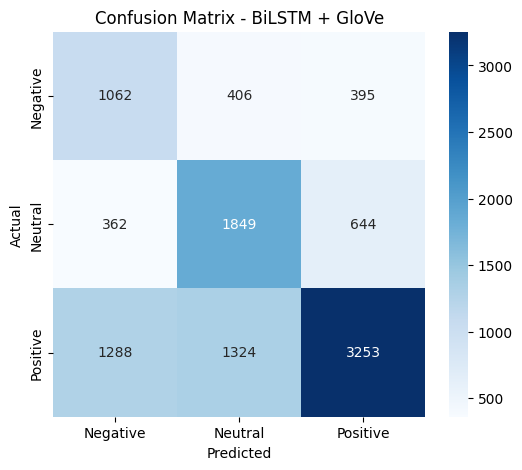

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BiLSTM + GloVe")
plt.show()

# Grafici

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# --- counts ---
train_counts = np.bincount(y_train)
val_counts   = np.bincount(y_val)
test_counts  = np.bincount(y_test)

def pad(arr, n=3):
    return np.pad(arr, (0, max(0, n - len(arr))))

train_counts = pad(train_counts)
val_counts   = pad(val_counts)
test_counts  = pad(test_counts)

labels = ['Negative', 'Neutral', 'Positive']

df_counts = pd.DataFrame({
    "Class": labels,
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
})

# --- style (same palette family as your donut) ---
colors = {
    "Train": "#4C6EF5",
    "Validation": "#F59F00",
    "Test": "#E03131"
}

fig = go.Figure()

for split in ["Train", "Validation", "Test"]:
    fig.add_trace(go.Bar(
        x=df_counts["Class"],
        y=df_counts[split],
        name=split,
        marker_color=colors[split],
        hovertemplate="<b>%{x}</b><br>"
                      f"Set: {split}<br>"
                      "Count: %{y:,}<extra></extra>",
    ))

fig.update_layout(
    title="Class Distribution: Train vs Validation vs Test",
    title_x=0.5,
    barmode="group",
    yaxis_title="Number of samples",

    # solo griglia orizzontale
    yaxis=dict(showgrid=True, gridcolor="rgba(255,255,255,0.2)", gridwidth=1),
    xaxis=dict(showgrid=False),

    # stile come il tuo plotly donut
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color="white"),

    legend_title_text="Set",
    legend=dict(
        title=dict(font=dict(size=16)),
        font=dict(size=14)
    ),
    margin=dict(t=80, l=60, r=40, b=50)
)

# tooltip “carino” con bordo bianco (come prima)
fig.update_traces(
    hoverlabel=dict(
        font=dict(color="white", size=12),
        bordercolor="white"
    )
)

fig.show()

In [ ]:
import numpy as np
import plotly.express as px

# --- Lunghezza description in parole ---
lengths = df['description'].fillna("").str.split().str.len()

# --- Percentili ---
ps = [15, 50, 75, 99]
pvals = {p: int(np.percentile(lengths, p)) for p in ps}

p99 = pvals[99]
max_len = int(lengths.max())

# --- Zoom fino a P99 ---
lengths_zoom = lengths[lengths <= p99]

# --- Istogramma ---
fig = px.histogram(
    x=lengths_zoom,
    nbins=60,
    title="Description Length Distribution (words) — up to P99",
    labels={"x": "Length (words)", "y": "Number of articles"}
)

# --- Stile coerente con i tuoi grafici ---
fig.update_layout(
    title_x=0.5,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color="white"),
    margin=dict(t=80, l=60, r=40, b=60),
    legend_title_text="Percentiles"
)

fig.update_yaxes(showgrid=True, gridcolor="rgba(255,255,255,0.2)")
fig.update_xaxes(showgrid=False)

# --- Colori percentili coerenti ---
percentile_colors = {
    15: "#E03131",   # rosso
    50: "#4C6EF5",   # blu
    75: "#F59F00",   # arancio
    99: "#9C36B5"    # viola
}

# --- Linee percentili (senza ymax hack) ---
for p in ps:
    fig.add_vline(
        x=pvals[p],
        line_width=3 if p == 99 else 2,
        line_dash="dash",
        line_color=percentile_colors[p],
        annotation_text=f"P{p}",
        annotation_position="top right"
    )

# --- Tooltip stile coerente ---
fig.update_traces(
    hoverlabel=dict(
        font=dict(color="white", size=12),
        bordercolor="white"
    )
)


fig.show()